# 03 — Label Consistency

Validate the annotation pipeline: rubric score computation, threshold-based ternary classification, and consistency between binary and rubric-derived labels.

**When labels don't exist yet** this notebook demonstrates what each check will look like using synthetic example data, so annotators can understand the expected structure before they begin.

### Rubric recap
Four components are scored per page:

| Component | Name | Range |
|---|---|---|
| D | Information Density | 0–3 (higher = more content) |
| H | Handwriting Dependence | 0–3 (higher = more handwriting) |
| S | Structural Clarity | 0–3 (higher = less clear) |
| L | Legibility | 0–3 (higher = worse legibility) |

**Risk formula**: `risk_score = (3 - D) + H + S + L`  →  range **0 – 12**

In [1]:
# Setup: imports
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

try:
    import seaborn as sns
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False
    print('seaborn not installed — using matplotlib only.')

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))
DATA_DIR = PROJECT_ROOT / 'data'

# Label threshold boundaries
THRESHOLD_SAFE   = 3   # risk_score <= THRESHOLD_SAFE  -> safe_for_extraction
THRESHOLD_REVIEW = 6   # THRESHOLD_SAFE < score <= THRESHOLD_REVIEW -> review
# risk_score > THRESHOLD_REVIEW -> high_hallucination_risk

print(f'Project root: {PROJECT_ROOT}')

seaborn not installed — using matplotlib only.
Project root: /Users/idan/projects/sandbox/for_tal


## 1. Load Annotation CSVs

In [2]:
# Load metadata, binary labels, and rubric labels — handle empty files gracefully
def load_csv_safe(path: Path, label: str) -> pd.DataFrame:
    """Load a CSV; return empty DataFrame (with columns from header) if it has no data rows."""
    try:
        df = pd.read_csv(path, encoding='utf-8-sig')
        if df.empty:
            print(f'[{label}] No data rows yet (header-only stub). Shape: {df.shape}')
        else:
            print(f'[{label}] Loaded {len(df)} rows, {df.shape[1]} columns.')
        return df
    except FileNotFoundError:
        print(f'[{label}] File not found: {path}')
        return pd.DataFrame()

meta_df    = load_csv_safe(DATA_DIR / 'metadata.csv',     'metadata')
binary_df  = load_csv_safe(DATA_DIR / 'labels_binary_clean.csv', 'labels_binary')
rubric_df  = load_csv_safe(DATA_DIR / 'labels_rubric.csv', 'labels_rubric')

LABELS_AVAILABLE = not rubric_df.empty and not binary_df.empty
print(f'\nLabels available for consistency checks: {LABELS_AVAILABLE}')
if not LABELS_AVAILABLE:
    print('\nNo labels yet — this notebook is ready for when annotations are available.')
    print('The cells below will demonstrate the checks with synthetic example data.')

[metadata] Loaded 1014 rows, 13 columns.
[labels_binary] Loaded 1014 rows, 5 columns.
[labels_rubric] Loaded 1014 rows, 8 columns.

Labels available for consistency checks: True


## 2. Rubric Score Formula

The risk score formula is:

```
risk_score = (3 - D) + H + S + L
```

- `(3 - D)` inverts density so **less content → higher risk**
- `H`, `S`, `L` all add risk directly
- Range: 0 (lowest risk) to 12 (highest risk)

In [3]:
# Demonstrate the risk_score formula with illustrative examples
def compute_risk_score(D: int, H: int, S: int, L: int) -> int:
    """risk_score = (3 - D) + H + S + L.  Range 0–12."""
    return (3 - D) + H + S + L

def classify_label(risk_score: int) -> str:
    if risk_score <= THRESHOLD_SAFE:
        return 'safe_for_extraction'
    elif risk_score <= THRESHOLD_REVIEW:
        return 'review'
    else:
        return 'high_hallucination_risk'

# Show worked examples across the score range
examples = [
    {'description': 'Dense typed doc, no handwriting, clear structure, fully legible',
     'D': 3, 'H': 0, 'S': 0, 'L': 0},
    {'description': 'Moderate content, light handwriting, some structure',
     'D': 2, 'H': 1, 'S': 1, 'L': 0},
    {'description': 'Sparse content, heavy handwriting, unclear structure',
     'D': 1, 'H': 2, 'S': 2, 'L': 1},
    {'description': 'Blank/template only, mostly handwriting, illegible',
     'D': 0, 'H': 3, 'S': 2, 'L': 2},
    {'description': 'Worst case: no content, all handwriting, structureless, illegible',
     'D': 0, 'H': 3, 'S': 3, 'L': 3},
]

rows = []
for ex in examples:
    rs = compute_risk_score(ex['D'], ex['H'], ex['S'], ex['L'])
    label = classify_label(rs)
    rows.append({**ex, 'risk_score': rs, 'label_ternary': label})

formula_df = pd.DataFrame(rows)
print('Risk score formula worked examples:')
display(formula_df)

Risk score formula worked examples:


,description,D,H,S,L,risk_score,label_ternary
0,"Dense typed doc, no handwriting, clear structu...",3,0,0,0,0,safe_for_extraction
1,"Moderate content, light handwriting, some stru...",2,1,1,0,3,safe_for_extraction
2,"Sparse content, heavy handwriting, unclear str...",1,2,2,1,7,high_hallucination_risk
3,"Blank/template only, mostly handwriting, illeg...",0,3,2,2,10,high_hallucination_risk
4,"Worst case: no content, all handwriting, struc...",0,3,3,3,12,high_hallucination_risk


## 3. Threshold Classification

Map risk scores to ternary labels:
- **0 – 3** → `safe_for_extraction`
- **4 – 6** → `review`  ← borderline / diagnostic set
- **7 – 12** → `high_hallucination_risk`

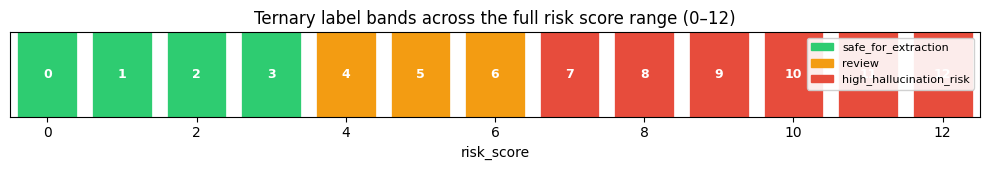

Thresholds: safe ≤ 3  |  review ≤ 6  |  high_risk > 6


In [4]:
# Visualise the threshold bands across the full 0–12 risk score range
score_range = np.arange(0, 13)
labels_all  = [classify_label(s) for s in score_range]

label_to_color = {
    'safe_for_extraction':    '#2ecc71',
    'review':                 '#f39c12',
    'high_hallucination_risk':'#e74c3c',
}
colors = [label_to_color[l] for l in labels_all]

fig, ax = plt.subplots(figsize=(10, 1.8))
for score, color, label in zip(score_range, colors, labels_all):
    ax.bar(score, 1, color=color, edgecolor='white', linewidth=0.5)
    ax.text(score, 0.5, str(score), ha='center', va='center', fontsize=9, fontweight='bold', color='white')

# Legend
patches = [mpatches.Patch(color=v, label=k) for k, v in label_to_color.items()]
ax.legend(handles=patches, loc='upper right', fontsize=8, framealpha=0.9)

ax.set_xlim(-0.5, 12.5)
ax.set_ylim(0, 1)
ax.set_xlabel('risk_score')
ax.set_yticks([])
ax.set_title('Ternary label bands across the full risk score range (0–12)')
plt.tight_layout()
plt.show()

print(f'Thresholds: safe ≤ {THRESHOLD_SAFE}  |  review ≤ {THRESHOLD_REVIEW}  |  high_risk > {THRESHOLD_REVIEW}')

## 4. Borderline Set Definition

The **borderline** (diagnostic) set contains all pages with `risk_score` in **4 – 6**.

These are the ambiguous cases that drive most annotation disagreement and calibration effort. They should be reviewed first when adjudicating contradictions between binary and rubric labels.

In [5]:
# Demonstrate borderline set extraction on real data (or synthetic if empty)
BORDERLINE_LOW  = THRESHOLD_SAFE + 1     # 4
BORDERLINE_HIGH = THRESHOLD_REVIEW       # 6

if LABELS_AVAILABLE and 'risk_score' in rubric_df.columns:
    borderline = rubric_df[
        (rubric_df['risk_score'] >= BORDERLINE_LOW) &
        (rubric_df['risk_score'] <= BORDERLINE_HIGH)
    ]
    total = len(rubric_df)
    pct = len(borderline) / total * 100 if total > 0 else 0
    print(f'Borderline cases (risk_score {BORDERLINE_LOW}–{BORDERLINE_HIGH}): '
          f'{len(borderline)} / {total} = {pct:.1f}%')
    display(borderline.head(10))
else:
    print(f'No rubric labels yet. Borderline = risk_score in [{BORDERLINE_LOW}, {BORDERLINE_HIGH}].')
    print('Example: the following synthetic rows would be borderline:')
    synthetic_borderline = pd.DataFrame([
        {'file_path': 'example_page_001.pdf', 'page_num': 1,
         'D': 1, 'H': 1, 'S': 2, 'L': 0, 'risk_score': 5, 'label_ternary': 'review'},
        {'file_path': 'example_page_002.pdf', 'page_num': 1,
         'D': 2, 'H': 2, 'S': 1, 'L': 1, 'risk_score': 5, 'label_ternary': 'review'},
        {'file_path': 'example_page_003.pdf', 'page_num': 1,
         'D': 0, 'H': 1, 'S': 1, 'L': 2, 'risk_score': 7, 'label_ternary': 'high_hallucination_risk'},
    ])
    display(synthetic_borderline)

Borderline cases (risk_score 4–6): 228 / 1014 = 22.5%


,file_path,page_num,D,H,S,L,risk_score,label_ternary
0,104-105נפומניאשצי_נתנאל_קטין_נ_מנורה_20260222_...,1,2,1,1,1,4,review
1,104-105נפומניאשצי_נתנאל_קטין_נ_מנורה_20260222_...,2,2,2,1,2,6,review
2,1cb73767-12db-4f08-be5e-bd5fb99dc6fd-2-36_page...,1,3,2,1,1,4,review
3,1cb73767-12db-4f08-be5e-bd5fb99dc6fd-2-36_page...,2,2,2,1,1,5,review
4,1cb73767-12db-4f08-be5e-bd5fb99dc6fd-2-36_page...,3,2,1,1,1,4,review
5,1cb73767-12db-4f08-be5e-bd5fb99dc6fd-2-36_page...,4,2,1,1,1,4,review
6,1cb73767-12db-4f08-be5e-bd5fb99dc6fd-2-36_page...,5,2,1,1,1,4,review
13,1cb73767-12db-4f08-be5e-bd5fb99dc6fd-2-36_page...,12,2,1,1,1,4,review
14,1cb73767-12db-4f08-be5e-bd5fb99dc6fd-2-36_page...,13,2,1,1,1,4,review
16,1cb73767-12db-4f08-be5e-bd5fb99dc6fd-2-36_page...,15,3,2,1,1,4,review


## 5. Label Consistency Check

Compare binary labels against rubric-derived ternary labels to flag contradictions.

**Expected alignment rule**: `label_binary == 1` (risky) should map to `high_hallucination_risk` or `review`; `label_binary == 0` (safe) should map to `safe_for_extraction`.  Any other combination is a contradiction.

In [6]:
# Label consistency check: binary vs rubric-derived labels
def check_consistency(binary_df: pd.DataFrame, rubric_df: pd.DataFrame) -> pd.DataFrame:
    """Merge binary and rubric labels on file_path + page_num and flag contradictions."""
    if binary_df.empty or rubric_df.empty:
        return pd.DataFrame()

    merge_keys = [k for k in ['file_path', 'page_num'] if k in binary_df.columns and k in rubric_df.columns]
    merged = binary_df.merge(rubric_df, on=merge_keys, how='inner', suffixes=('_bin', '_rub'))

    if merged.empty:
        print('No overlapping pages between binary and rubric labels yet.')
        return merged

    # Derive ternary label from rubric scores if not already present
    if 'label_ternary' not in merged.columns:
        merged['label_ternary'] = merged['risk_score'].apply(classify_label)

    # A contradiction is: binary=0 (safe) but rubric says risky or review
    #                   OR binary=1 (risky) but rubric says safe
    def is_contradiction(row):
        b = row.get('label_binary')
        t = row.get('label_ternary')
        if pd.isna(b) or pd.isna(t):
            return False
        if b == 0 and t in ('review', 'high_hallucination_risk'):
            return True
        if b == 1 and t == 'safe_for_extraction':
            return True
        return False

    merged['contradiction'] = merged.apply(is_contradiction, axis=1)
    return merged


if LABELS_AVAILABLE:
    consistency_df = check_consistency(binary_df, rubric_df)
    if not consistency_df.empty:
        n_total = len(consistency_df)
        n_contra = consistency_df['contradiction'].sum()
        print(f'Pages with both labels: {n_total}')
        print(f'Contradictions        : {n_contra} ({n_contra/n_total*100:.1f}%)')
        if n_contra > 0:
            print('\nContradiction rows (first 20):')
            display(consistency_df[consistency_df['contradiction']].head(20))
        else:
            print('No contradictions found. ✓')
else:
    # Demonstrate with synthetic data
    print('No labels yet — demonstrating consistency check with synthetic data:')
    synth_binary = pd.DataFrame([
        {'file_path': 'page_A.pdf', 'page_num': 1, 'label_binary': 0},
        {'file_path': 'page_B.pdf', 'page_num': 1, 'label_binary': 1},
        {'file_path': 'page_C.pdf', 'page_num': 1, 'label_binary': 0},  # contradiction below
        {'file_path': 'page_D.pdf', 'page_num': 1, 'label_binary': 1},
    ])
    synth_rubric = pd.DataFrame([
        {'file_path': 'page_A.pdf', 'page_num': 1, 'D': 3, 'H': 0, 'S': 0, 'L': 0,
         'risk_score': 0, 'label_ternary': 'safe_for_extraction'},
        {'file_path': 'page_B.pdf', 'page_num': 1, 'D': 0, 'H': 3, 'S': 2, 'L': 2,
         'risk_score': 10, 'label_ternary': 'high_hallucination_risk'},
        {'file_path': 'page_C.pdf', 'page_num': 1, 'D': 0, 'H': 2, 'S': 2, 'L': 3,
         'risk_score': 10, 'label_ternary': 'high_hallucination_risk'},  # binary=0, ternary=risky -> contradiction!
        {'file_path': 'page_D.pdf', 'page_num': 1, 'D': 2, 'H': 0, 'S': 0, 'L': 0,
         'risk_score': 1, 'label_ternary': 'safe_for_extraction'},        # binary=1, ternary=safe -> contradiction!
    ])
    demo_consistency = check_consistency(synth_binary, synth_rubric)
    print(f'Synthetic pages checked: {len(demo_consistency)}')
    print(f'Contradictions found   : {demo_consistency["contradiction"].sum()}')
    display(demo_consistency)

Pages with both labels: 1014
Contradictions        : 242 (23.9%)

Contradiction rows (first 20):


,file_path,page_num,label_binary,drive_link,drive_id,D,H,S,L,risk_score,label_ternary,contradiction
6,2cef1ae8-c6d5-4905-a062-5c0e79438fc1_page_0007...,7,0,https://drive.google.com/file/d/1g4FPyqqxZIb7E...,1g4FPyqqxZIb7EBmlOo5Vl6bZsN5SH3Fc,1,1,1,2,6,review,True
7,7eab033e-0e68-46c2-aff0-6a585129fa00_page_0001...,1,0,https://drive.google.com/file/d/1hf5jz_hZ4PByj...,1hf5jz_hZ4PByjS67sntgysTzwxG4cEeG,2,0,1,2,4,review,True
8,7eab033e-0e68-46c2-aff0-6a585129fa00_page_0002...,2,0,https://drive.google.com/file/d/1NgnMvuP9T5jPJ...,1NgnMvuP9T5jPJhu1KbkOzGZwvhL8S1xN,2,0,1,2,4,review,True
10,7eab033e-0e68-46c2-aff0-6a585129fa00_page_0004...,4,0,https://drive.google.com/file/d/1WIhrrRBdPUMey...,1WIhrrRBdPUMeyvUEyC3Yxi1X062o7m10,2,0,1,2,4,review,True
11,7eab033e-0e68-46c2-aff0-6a585129fa00_page_0005...,5,0,https://drive.google.com/file/d/1OJjd7Zle19Sm5...,1OJjd7Zle19Sm5ZpyPyyVEqMBbK88Uz-N,2,0,1,2,4,review,True
14,7eab033e-0e68-46c2-aff0-6a585129fa00_page_0008...,8,0,https://drive.google.com/file/d/1W-Uwo8XLw5BU1...,1W-Uwo8XLw5BU1pWfk8A-ywFiexEaDjVr,1,0,1,1,4,review,True
15,7eab033e-0e68-46c2-aff0-6a585129fa00_page_0009...,9,0,https://drive.google.com/file/d/1Xgd1vw2kemMkJ...,1Xgd1vw2kemMkJBoCvqolcntTykMtqTbD,2,1,1,1,4,review,True
17,7eab033e-0e68-46c2-aff0-6a585129fa00_page_0011...,11,0,https://drive.google.com/file/d/1oq-KeHFdI7jkq...,1oq-KeHFdI7jkqUWnxK-V1xITeeKL3GMR,2,1,1,2,5,review,True
18,7eab033e-0e68-46c2-aff0-6a585129fa00_page_0012...,12,0,https://drive.google.com/file/d/1xWTL_pYs34K45...,1xWTL_pYs34K45tx9GS4jUJLNjb2vMuJC,2,1,1,1,4,review,True
20,7eab033e-0e68-46c2-aff0-6a585129fa00_page_0014...,14,0,https://drive.google.com/file/d/1JqrIaYJhePFy-...,1JqrIaYJhePFy-RR-eRpWCxVp8ohCMDG4,2,0,1,2,4,review,True


## 6. Risk Score Distribution (Simulation)

Simulate realistic D/H/S/L scores to illustrate the expected risk score distribution for the full annotated dataset. This helps set expectations before annotation begins.

Simulated N=500 pages

Label distribution (simulated):
label_ternary
safe_for_extraction        233
review                     145
high_hallucination_risk    122

Risk score stats:
count    500.000000
mean       4.278000
std        2.808646
min        0.000000
25%        2.000000
50%        4.000000
75%        6.000000
max       12.000000


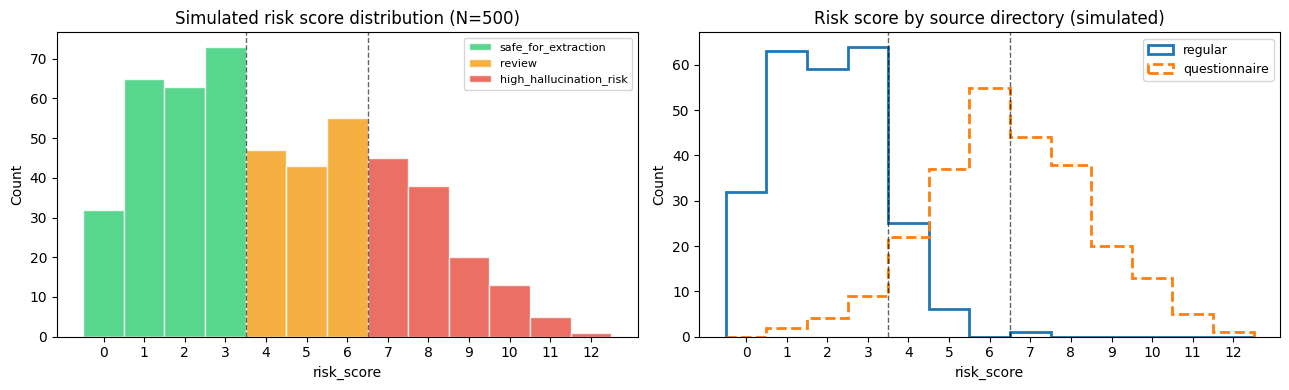

In [7]:
# Simulate risk score distribution with plausible D/H/S/L distributions
rng = np.random.default_rng(42)
N_SIM = 500

# מסמכים רגילים (regular docs) — tend to be dense, low handwriting, clear structure
D_regular = rng.choice([2, 3], size=N_SIM // 2, p=[0.4, 0.6])
H_regular = rng.choice([0, 1, 2], size=N_SIM // 2, p=[0.6, 0.3, 0.1])
S_regular = rng.choice([0, 1, 2], size=N_SIM // 2, p=[0.5, 0.35, 0.15])
L_regular = rng.choice([0, 1, 2], size=N_SIM // 2, p=[0.6, 0.3, 0.1])

# pdf_s - שאלונים וכתב יד (questionnaires) — mixed; often handwriting-heavy
D_quest = rng.choice([0, 1, 2, 3], size=N_SIM // 2, p=[0.25, 0.35, 0.25, 0.15])
H_quest = rng.choice([0, 1, 2, 3], size=N_SIM // 2, p=[0.15, 0.25, 0.35, 0.25])
S_quest = rng.choice([0, 1, 2, 3], size=N_SIM // 2, p=[0.2, 0.3, 0.3, 0.2])
L_quest = rng.choice([0, 1, 2, 3], size=N_SIM // 2, p=[0.2, 0.3, 0.3, 0.2])

D_all = np.concatenate([D_regular, D_quest])
H_all = np.concatenate([H_regular, H_quest])
S_all = np.concatenate([S_regular, S_quest])
L_all = np.concatenate([L_regular, L_quest])
source_all = ['regular'] * (N_SIM // 2) + ['questionnaire'] * (N_SIM // 2)

sim_df = pd.DataFrame({'D': D_all, 'H': H_all, 'S': S_all, 'L': L_all, 'source': source_all})
sim_df['risk_score']    = sim_df.apply(lambda r: compute_risk_score(r.D, r.H, r.S, r.L), axis=1)
sim_df['label_ternary'] = sim_df['risk_score'].apply(classify_label)

# Summary stats
print(f'Simulated N={N_SIM} pages')
print('\nLabel distribution (simulated):')
print(sim_df['label_ternary'].value_counts().to_string())
print(f'\nRisk score stats:')
print(sim_df['risk_score'].describe().to_string())

# Plot histogram
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Overall distribution with colored bands
ax = axes[0]
bins = np.arange(-0.5, 13.5, 1)
for label, color in label_to_color.items():
    mask = sim_df['label_ternary'] == label
    ax.hist(sim_df.loc[mask, 'risk_score'], bins=bins, color=color,
            alpha=0.8, edgecolor='white', label=label)
ax.axvline(THRESHOLD_SAFE + 0.5,   color='black', linestyle='--', lw=1, alpha=0.6)
ax.axvline(THRESHOLD_REVIEW + 0.5, color='black', linestyle='--', lw=1, alpha=0.6)
ax.set_xlabel('risk_score')
ax.set_ylabel('Count')
ax.set_title('Simulated risk score distribution (N=500)')
ax.legend(fontsize=8)
ax.set_xticks(range(0, 13))

# Per-source breakdown
ax2 = axes[1]
for src, linestyle in [('regular', '-'), ('questionnaire', '--')]:
    subset = sim_df[sim_df['source'] == src]['risk_score']
    ax2.hist(subset, bins=bins, histtype='step', lw=2, linestyle=linestyle, label=src)
ax2.axvline(THRESHOLD_SAFE + 0.5,   color='black', linestyle='--', lw=1, alpha=0.6)
ax2.axvline(THRESHOLD_REVIEW + 0.5, color='black', linestyle='--', lw=1, alpha=0.6)
ax2.set_xlabel('risk_score')
ax2.set_ylabel('Count')
ax2.set_title('Risk score by source directory (simulated)')
ax2.legend(fontsize=9)
ax2.set_xticks(range(0, 13))

plt.tight_layout()
plt.show()

## 7. When Real Labels Arrive: Full Pipeline Preview

Once labels are available, this cell computes and plots the **actual** distribution.

Real label distribution:
label_ternary
safe_for_extraction        676
review                     228
high_hallucination_risk    110
Name: count, dtype: int64


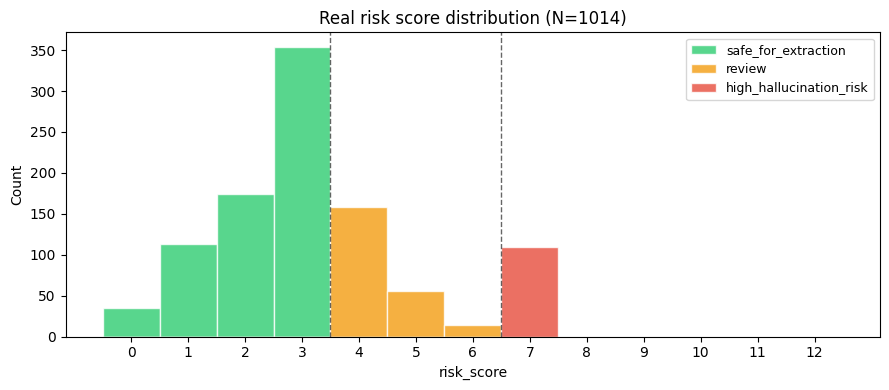

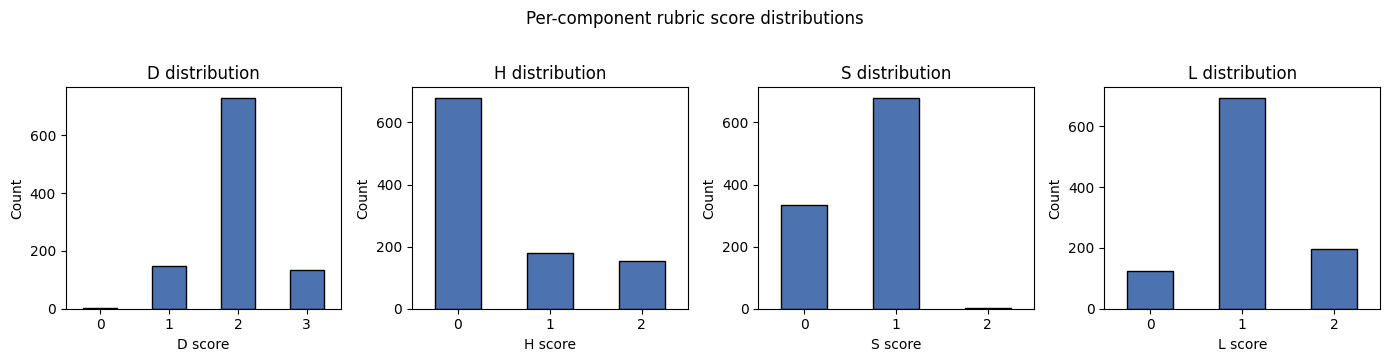

In [8]:
# Plot real label distribution when rubric data is available
if LABELS_AVAILABLE and 'risk_score' in rubric_df.columns:
    real_df = rubric_df.copy()
    if 'label_ternary' not in real_df.columns:
        real_df['label_ternary'] = real_df['risk_score'].apply(classify_label)

    print('Real label distribution:')
    print(real_df['label_ternary'].value_counts())

    fig, ax = plt.subplots(figsize=(9, 4))
    bins = np.arange(-0.5, 13.5, 1)
    for label, color in label_to_color.items():
        mask = real_df['label_ternary'] == label
        ax.hist(real_df.loc[mask, 'risk_score'], bins=bins, color=color,
                alpha=0.8, edgecolor='white', label=label)
    ax.axvline(THRESHOLD_SAFE + 0.5,   color='black', linestyle='--', lw=1, alpha=0.6)
    ax.axvline(THRESHOLD_REVIEW + 0.5, color='black', linestyle='--', lw=1, alpha=0.6)
    ax.set_xlabel('risk_score')
    ax.set_ylabel('Count')
    ax.set_title(f'Real risk score distribution (N={len(real_df)})')
    ax.legend(fontsize=9)
    ax.set_xticks(range(0, 13))
    plt.tight_layout()
    plt.show()

    # Per-component score distributions
    fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
    for ax, comp in zip(axes, ['D', 'H', 'S', 'L']):
        if comp in real_df.columns:
            real_df[comp].value_counts().sort_index().plot(
                kind='bar', ax=ax, color='#4C72B0', edgecolor='black'
            )
            ax.set_title(f'{comp} distribution')
            ax.set_xlabel(f'{comp} score')
            ax.set_ylabel('Count')
            ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    plt.suptitle('Per-component rubric score distributions', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('Real labels not yet available. Re-run this cell after annotation is complete.')

## 8. Annotation Guide Summary

Quick reference for annotators, reproduced from the project plan.

---

### Safe examples (`label_binary = 0`, expected `risk_score ≤ 3`)

- Typed or printed documents with substantial filled content (letters, medical summaries, full reports)
- Questionnaires where most fields are filled with clear typed or printed text
- Documents with clear visual structure (headers, tables, defined sections) and readable text throughout

**Typical scores**: D=3, H=0–1, S=0–1, L=0–1 → `risk_score` 0–3

---

### Review examples (`review`, expected `risk_score 4–6`)

- Partially filled questionnaires where some handwriting is present but the printed fields still carry enough context
- Documents with moderate handwriting that is mostly legible
- Pages where structure is clear but content density is low

**Typical scores**: D=1–2, H=1–2, S=1–2, L=0–1 → `risk_score` 4–6

---

### High hallucination risk examples (`label_binary = 1`, expected `risk_score ≥ 7`)

- Mostly blank questionnaires (few or no fields filled)
- Pages dominated by illegible handwriting with little printed context
- Structureless free-form scanned documents with heavy handwriting overlap
- Pages with low contrast, heavy skew, or significant scanning artifacts

**Typical scores**: D=0–1, H=2–3, S=2–3, L=2–3 → `risk_score` 7–12

---

### Annotation quality targets
| Metric | Target |
|---|---|
| Inter-annotator agreement (Cohen κ) | ≥ 0.75 |
| Contradiction rate (binary vs rubric) | < 5% |
| Borderline set coverage (`review` band) | 15–30% of total |
| False-safe rate after calibration | ≤ 5% per institution |